## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

## Load Data

In [2]:
pd.set_option('display.max_columns', None)

df = pd.read_excel('E Commerce Dataset.xlsx',sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### Data Understanding

In [3]:
print (f'Data shape: {df.shape}')

Data shape: (5630, 20)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Check and Fix Data (if necessary)

In [5]:
#check objects data dtypes
categorical_columns = df.select_dtypes(include='object')
for columns in categorical_columns:
  print(df[columns].value_counts())
  print('====================')

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
Gender
Male      3384
Female    2246
Name: count, dtype: int64
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


### Handle Missing Data

In [6]:
#check missing values
missing = df.isnull().sum().reset_index()
missing.columns = ['features', 'missing_values']
missing['percentage'] = (missing['missing_values']/len(df)) *100
missing

,features,missing_values,percentage
0,CustomerID,0,0.000000
1,Churn,0,0.000000
2,Tenure,264,4.689165
3,PreferredLoginDevice,0,0.000000
4,CityTier,0,0.000000
5,WarehouseToHome,251,4.458259
6,PreferredPaymentMode,0,0.000000
7,Gender,0,0.000000
8,HourSpendOnApp,255,4.529307
9,NumberOfDeviceRegistered,0,0.000000


because the missing value more than 20%, we're not going to drop them. we going to handle them to fill the missing value with median

In [7]:
# Handling missing values untuk setiap kolom

# Kolom numerik - imputasi dengan median
numerical_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                 'DaySinceLastOrder']

for col in numerical_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    print(f"Kolom {col}: diisi dengan median = {median_value}")

Kolom Tenure: diisi dengan median = 9.0
Kolom WarehouseToHome: diisi dengan median = 14.0
Kolom HourSpendOnApp: diisi dengan median = 3.0
Kolom OrderAmountHikeFromlastYear: diisi dengan median = 15.0
Kolom CouponUsed: diisi dengan median = 1.0
Kolom OrderCount: diisi dengan median = 2.0
Kolom DaySinceLastOrder: diisi dengan median = 3.0


/tmp/ipython-input-3358971351.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


In [8]:
# verifikasi setelah handling
print("\nMissing values setelah handling:")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])

# Tampilkan info dataset setelah handling missing values
print("\nInfo dataset setelah handling missing values:")
print(df.info())


Missing values setelah handling:
Series([], dtype: int64)

Info dataset setelah handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore           

### Handle Duplicated Data

In [9]:
#Check ratio of unique values
len(df.drop_duplicates(subset = ['CustomerID'])) / len(df)

1.0

There is no duplicated data

In [10]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,10.134103,1.654707,15.566785,2.934636,3.688988,3.066785,4.214032,0.284902,15.674600,1.716874,2.961812,4.459325,177.223030
std,1625.385339,0.374240,8.357951,0.915389,8.345961,0.705528,1.023999,1.380194,2.583586,0.451408,3.591058,1.857640,2.879248,3.570626,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


###Handle Outlier

In [37]:
numeric_cols=df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [38]:
import scipy.stats as stats

def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

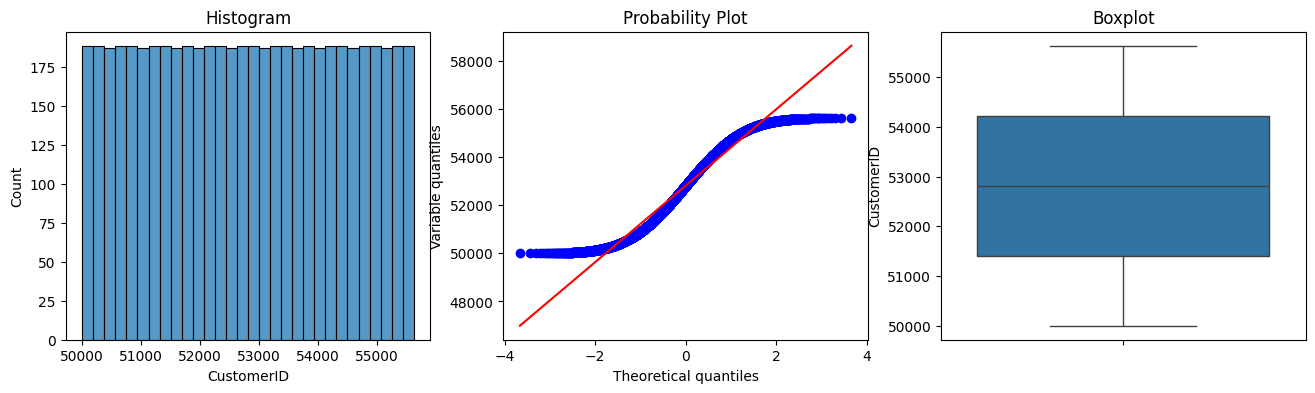

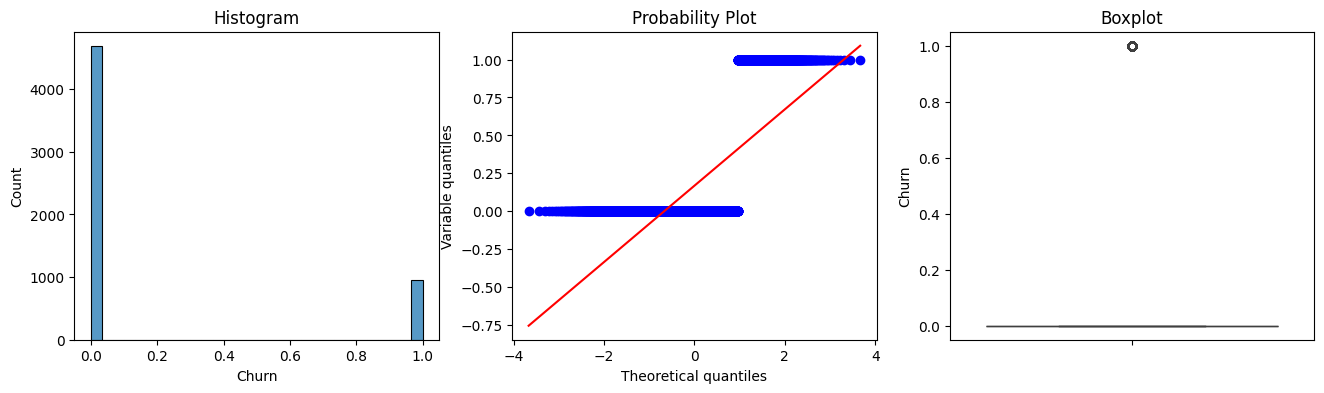

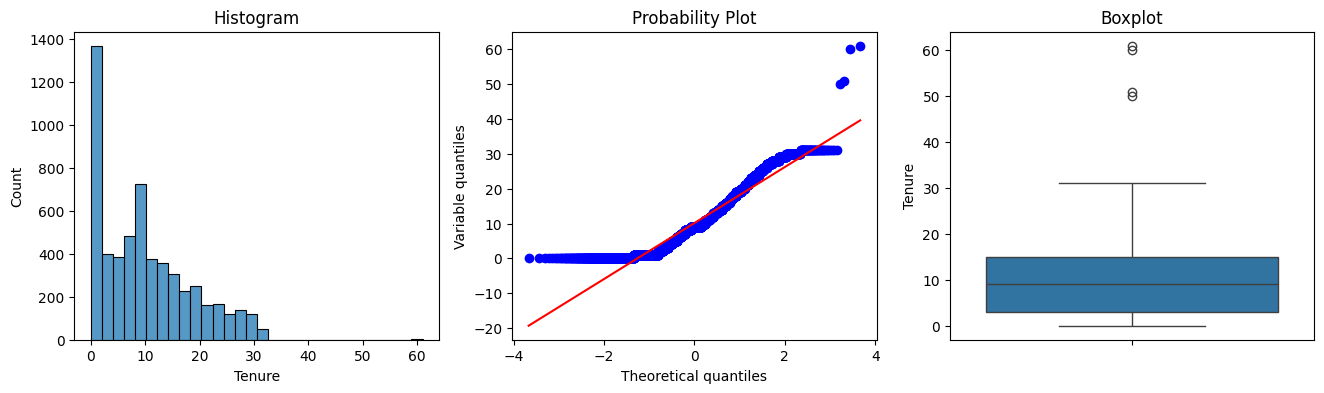

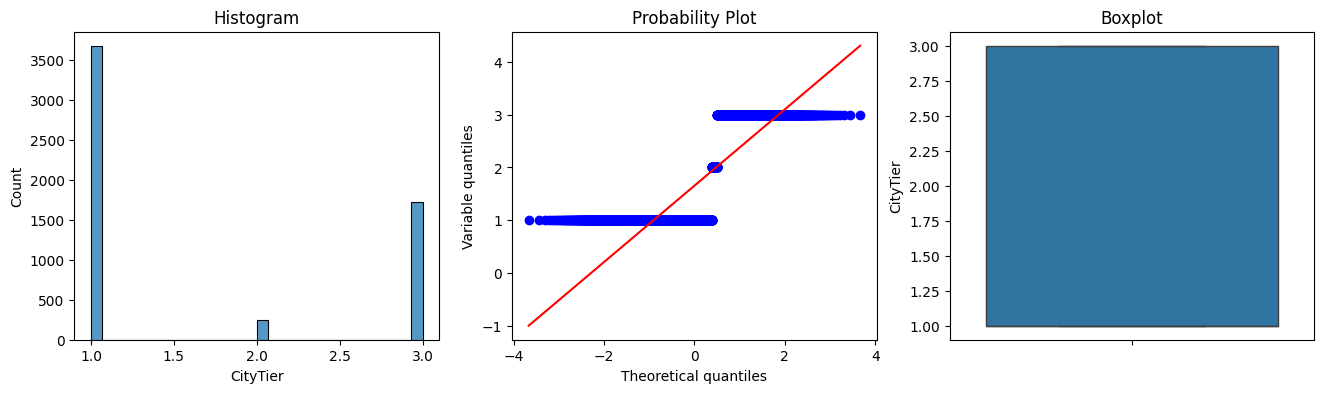

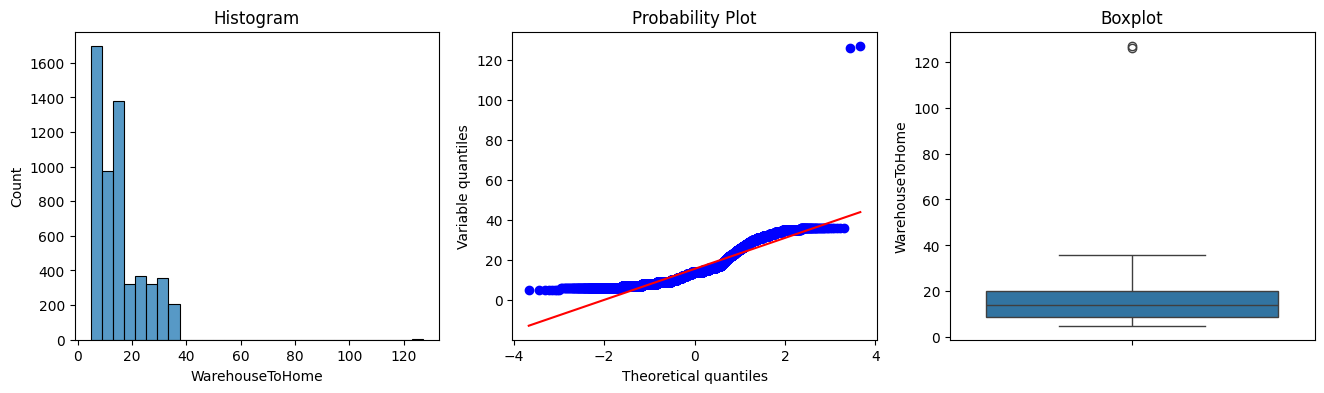

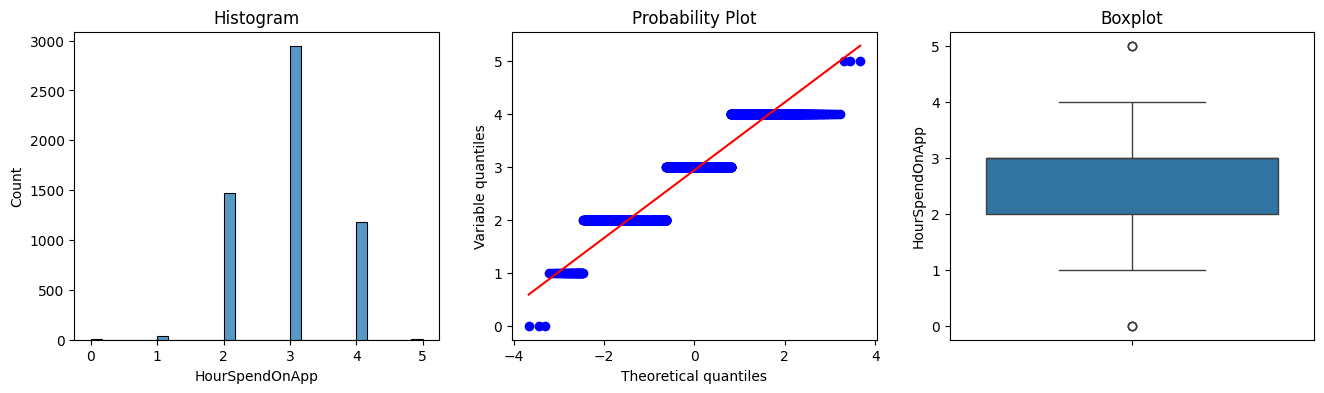

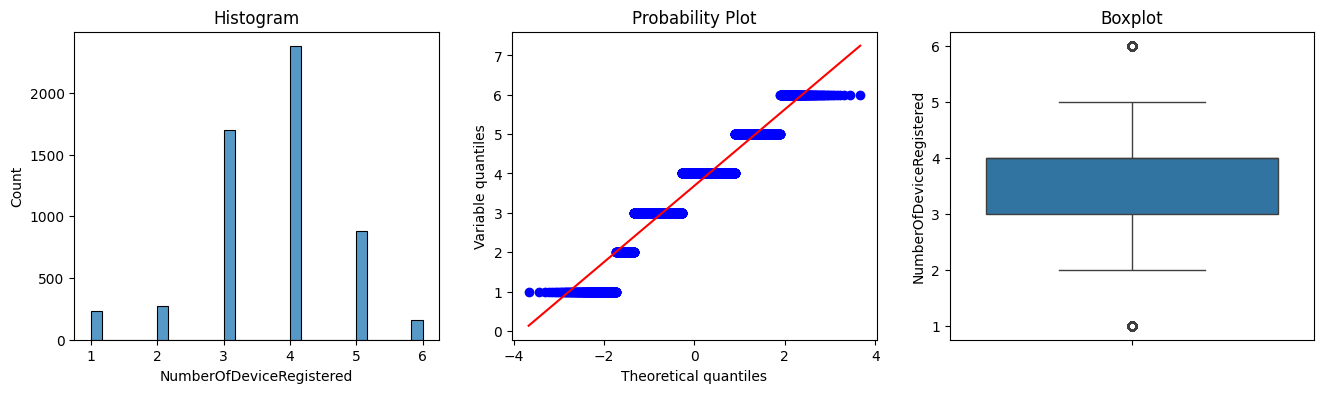

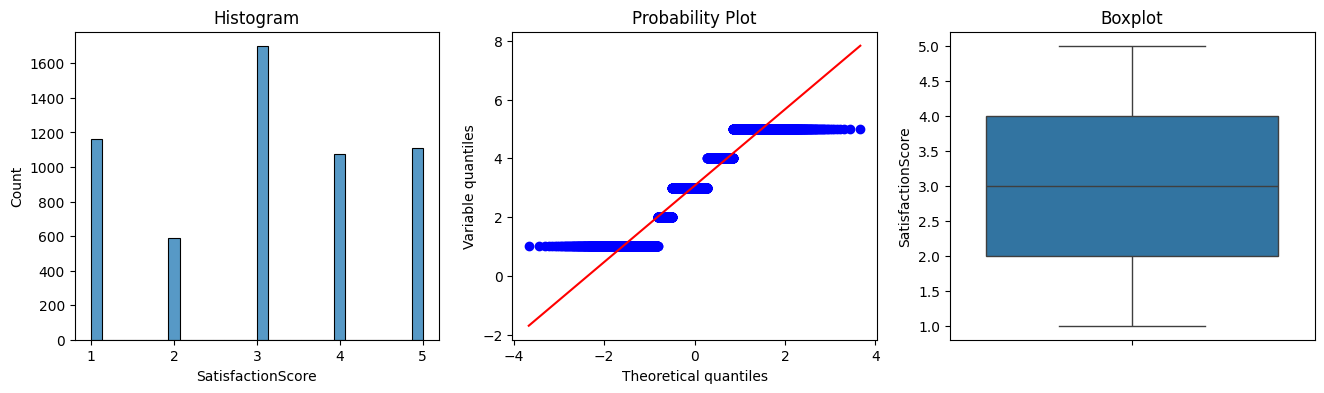

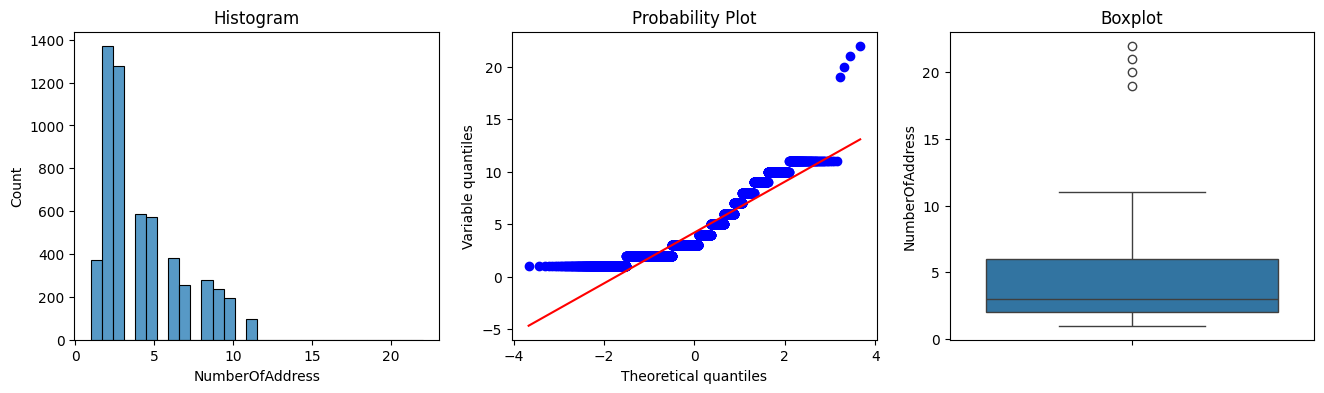

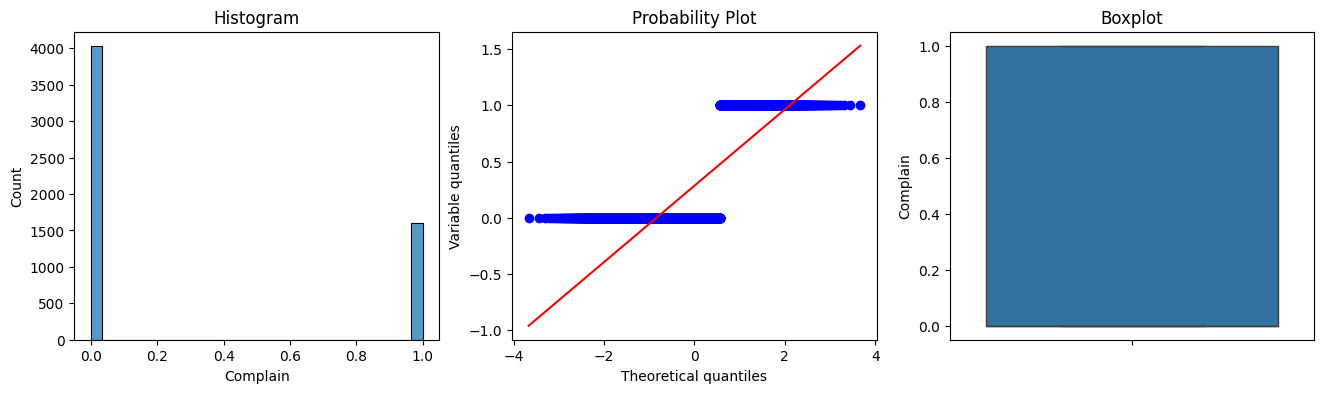

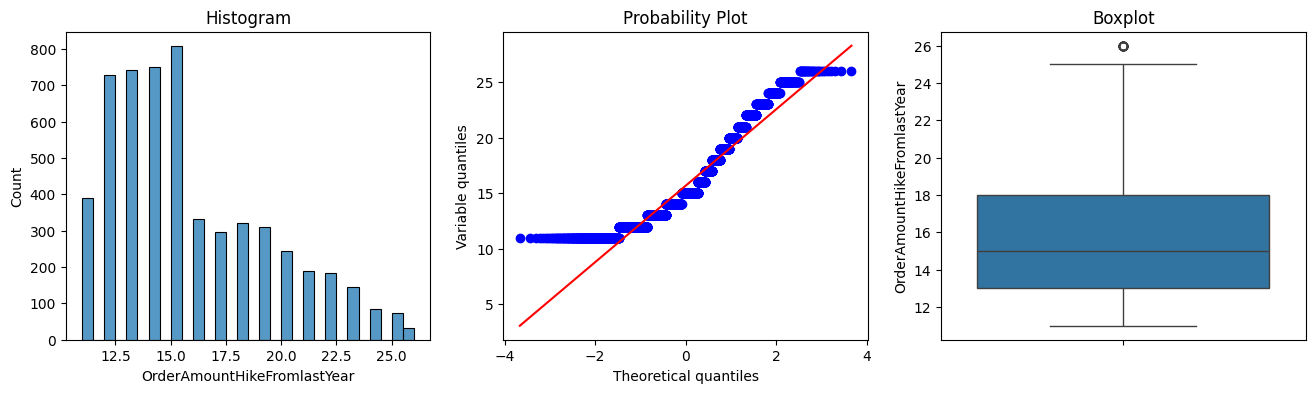

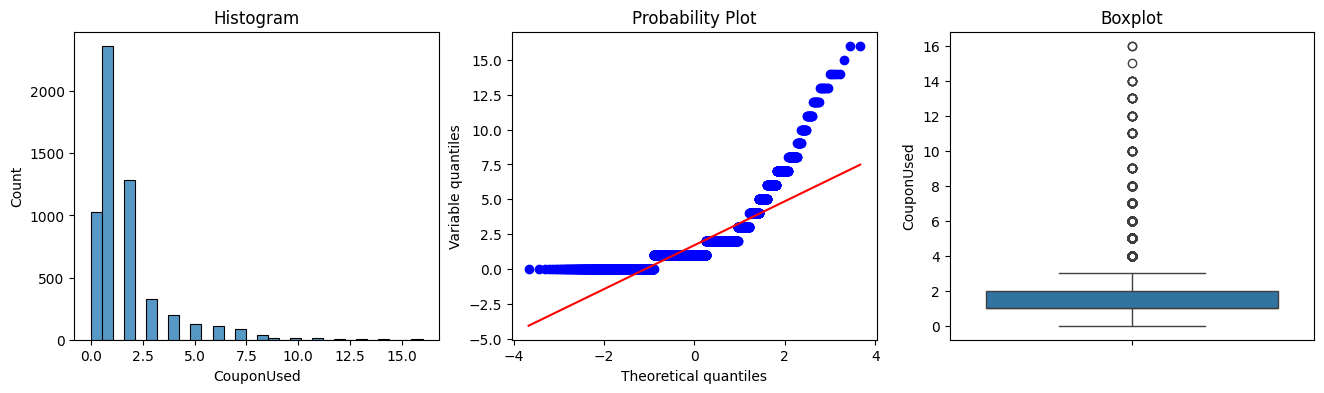

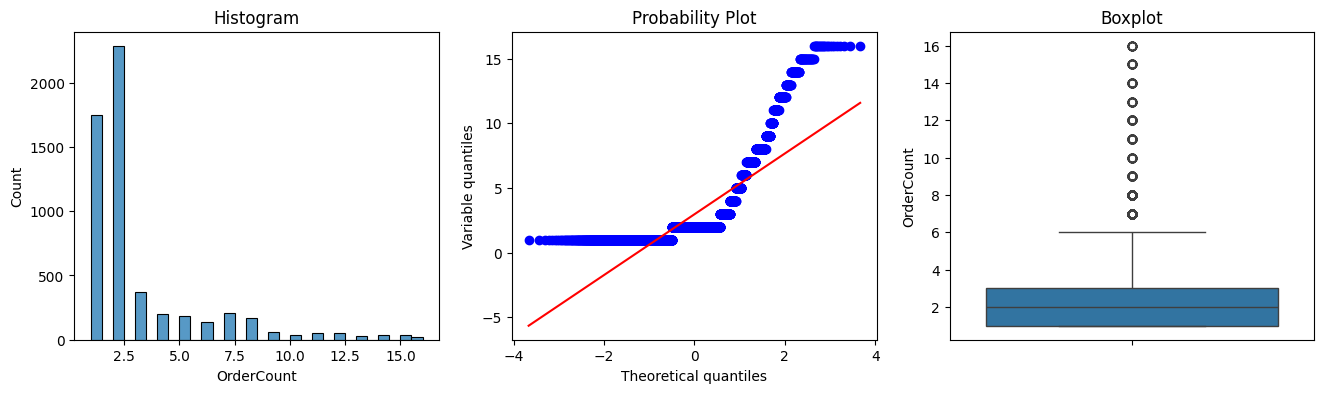

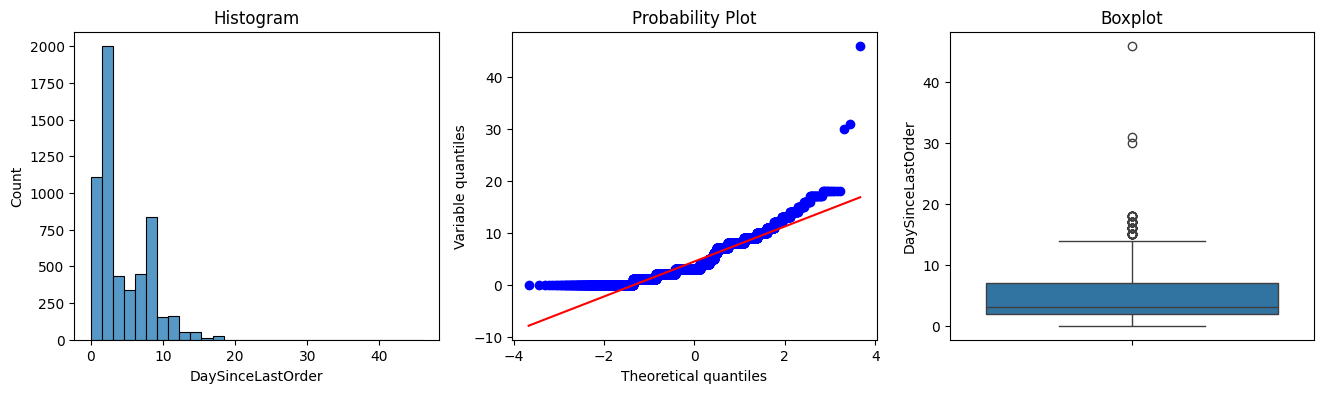

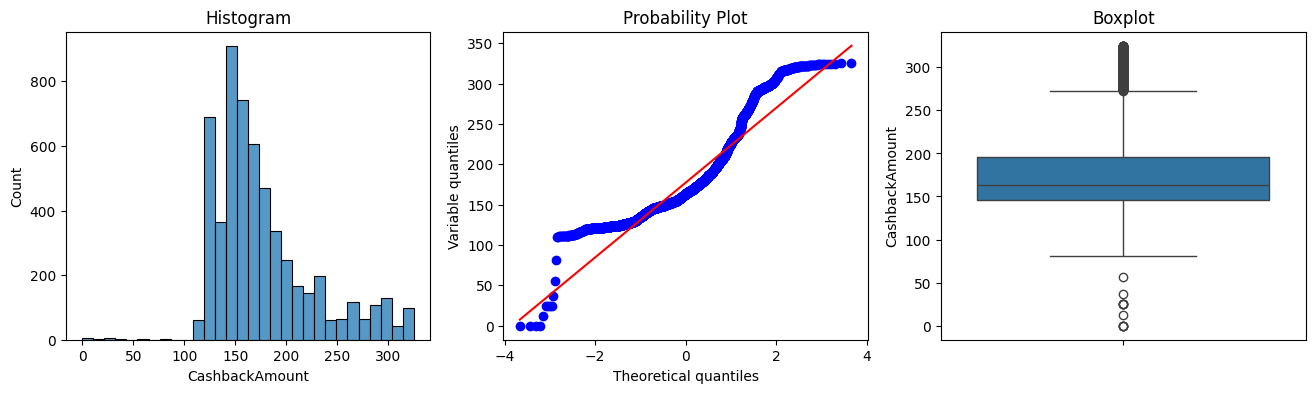

In [39]:
# Terapkan check_plot pada setiap kolom numerik
for col in numeric_cols:
    check_plot(df, col)

the  outlier in those coloumns are reasonable.

## Data Cleaning_Machine Learning

In [13]:
data_ml = df.copy()

In [14]:
data_ml = data_ml.set_index("CustomerID").drop(columns=["CustomerID"], errors="ignore")

In [17]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
train_df, test_df = train_test_split(data_ml, test_size = 0.2, random_state=42)

### Encode Categorical Variables for Training Set

In [18]:
train_encoded = train_df.copy()


In [19]:
#encode TripReason
train_encoded['Gender'] = train_encoded['Gender'].map({'Male': 0, 'Female': 1}).astype(int)

In [22]:
#mean encoding
pld_mean = train_encoded.groupby('PreferredLoginDevice', observed=True)['Churn'].mean().to_dict()
print(pld_mean)

ppm_mean = train_encoded.groupby('PreferredPaymentMode', observed=True)['Churn'].mean().to_dict()
print(ppm_mean)

poc_mean = train_encoded.groupby('PreferedOrderCat', observed=True)['Churn'].mean().to_dict()
print(poc_mean)

ms_mean = train_encoded.groupby('MaritalStatus', observed=True)['Churn'].mean().to_dict()
print(ms_mean)

train_encoded['PreferredLoginDevice'] = train_encoded['PreferredLoginDevice'].map(pld_mean).astype(float)
train_encoded['PreferredPaymentMode'] = train_encoded['PreferredPaymentMode'].map(ppm_mean).astype(float)
train_encoded['PreferedOrderCat'] = train_encoded['PreferedOrderCat'].map(poc_mean).astype(float)
train_encoded['MaritalStatus'] = train_encoded['MaritalStatus'].map(ms_mean).astype(float)

{'Computer': 0.2003046458492003, 'Mobile Phone': 0.12494341330918968, 'Phone': 0.22810590631364563}
{'CC': 0.21585903083700442, 'COD': 0.27181208053691275, 'Cash on Delivery': 0.16393442622950818, 'Credit Card': 0.13383838383838384, 'Debit Card': 0.15609756097560976, 'E wallet': 0.22745901639344263, 'UPI': 0.1636904761904762}
{'Fashion': 0.15241057542768274, 'Grocery': 0.048484848484848485, 'Laptop & Accessory': 0.10523114355231143, 'Mobile': 0.2711864406779661, 'Mobile Phone': 0.28, 'Others': 0.06103286384976526}
{'Divorced': 0.14200298953662183, 'Married': 0.11602671118530884, 'Single': 0.2710215427380125}


In [23]:
train_encoded.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
CustomerID,,,,,,,,,,,,,,,,,,,
54479,0,1.0,0.124943,1,12.0,0.156098,1,3.0,4,0.280000,4,0.271022,3,1,13.0,1.0,2.0,3.0,149.78
53686,0,17.0,0.124943,1,13.0,0.133838,1,4.0,5,0.105231,3,0.271022,3,1,15.0,2.0,2.0,9.0,165.81
50732,0,0.0,0.228106,1,9.0,0.156098,0,3.0,4,0.271186,3,0.271022,2,0,12.0,0.0,1.0,2.0,130.33
50292,0,9.0,0.200305,1,8.0,0.156098,0,2.0,3,0.280000,2,0.142003,2,1,23.0,1.0,1.0,0.0,117.02
50185,0,4.0,0.228106,1,11.0,0.271812,0,2.0,3,0.280000,2,0.142003,1,1,12.0,0.0,1.0,3.0,148.21


### Encode Categorical Variables for Testing Set

In [24]:
test_encoded = test_df.copy()

In [25]:
#encode TripReason
test_encoded['Gender'] = test_encoded['Gender'].map({'Male': 0, 'Female': 1}).astype(int)


In [26]:
#mean encoding for From, To, and Vehicle
pld_mean_test = test_encoded.groupby('PreferredLoginDevice', observed=True)['Churn'].mean().to_dict()
print(pld_mean)

ppm_mean_test = test_encoded.groupby('PreferredPaymentMode', observed=True)['Churn'].mean().to_dict()
print(ppm_mean)

poc_mean_test = test_encoded.groupby('PreferedOrderCat', observed=True)['Churn'].mean().to_dict()
print(poc_mean)

ms_mean_test = test_encoded.groupby('MaritalStatus', observed=True)['Churn'].mean().to_dict()
print(ms_mean)

test_encoded['PreferredLoginDevice'] = test_encoded['PreferredLoginDevice'].map(pld_mean_test).astype(float)
test_encoded['PreferredPaymentMode'] = test_encoded['PreferredPaymentMode'].map(ppm_mean_test).astype(float)
test_encoded['PreferedOrderCat'] = test_encoded['PreferedOrderCat'].map(poc_mean_test).astype(float)
test_encoded['MaritalStatus'] = test_encoded['MaritalStatus'].map(ms_mean_test).astype(float)

{'Computer': 0.2003046458492003, 'Mobile Phone': 0.12494341330918968, 'Phone': 0.22810590631364563}
{'CC': 0.21585903083700442, 'COD': 0.27181208053691275, 'Cash on Delivery': 0.16393442622950818, 'Credit Card': 0.13383838383838384, 'Debit Card': 0.15609756097560976, 'E wallet': 0.22745901639344263, 'UPI': 0.1636904761904762}
{'Fashion': 0.15241057542768274, 'Grocery': 0.048484848484848485, 'Laptop & Accessory': 0.10523114355231143, 'Mobile': 0.2711864406779661, 'Mobile Phone': 0.28, 'Others': 0.06103286384976526}
{'Divorced': 0.14200298953662183, 'Married': 0.11602671118530884, 'Single': 0.2710215427380125}


In [27]:
test_encoded.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
CustomerID,,,,,,,,,,,,,,,,,,,
54332,1,1.0,0.190031,3,7.0,0.358209,1,4.0,6,0.256098,5,0.252101,2,0,22.0,2.0,2.0,1.0,148.25
51989,0,15.0,0.129496,1,9.0,0.144989,1,3.0,1,0.091133,1,0.111864,3,1,13.0,1.0,1.0,3.0,152.31
53444,0,13.0,0.190031,1,29.0,0.108626,1,3.0,4,0.163934,5,0.252101,3,1,14.0,2.0,2.0,9.0,233.80
54560,0,5.0,0.208835,1,7.0,0.144989,0,4.0,5,0.256098,5,0.111864,3,0,13.0,4.0,4.0,3.0,147.18
54899,0,13.0,0.129496,1,7.0,0.144989,1,4.0,5,0.050000,1,0.111864,3,0,17.0,10.0,2.0,9.0,252.42


## Pre-Processing

### Check Multicollinearity of Variables

In [29]:
Z = train_encoded.copy()
Z['constant'] = 1

#compute VIF
vif_data = pd.DataFrame({
    'Variable': Z.columns,
    'VIF': [variance_inflation_factor(Z.values, i) for i in range(Z.shape[1])]
})

vif_data = vif_data[vif_data['Variable'] != 'constant'].sort_values(by='VIF', ascending=False)

print(vif_data)

                       Variable       VIF
18               CashbackAmount  2.345863
9              PreferedOrderCat  2.161553
16                   OrderCount  1.996207
15                   CouponUsed  1.784023
1                        Tenure  1.526475
17            DaySinceLastOrder  1.374522
0                         Churn  1.366232
2          PreferredLoginDevice  1.352818
7                HourSpendOnApp  1.246929
3                      CityTier  1.204163
12              NumberOfAddress  1.168274
8      NumberOfDeviceRegistered  1.161788
5          PreferredPaymentMode  1.128471
13                     Complain  1.090883
11                MaritalStatus  1.055560
10            SatisfactionScore  1.027089
4               WarehouseToHome  1.019322
14  OrderAmountHikeFromlastYear  1.018104
6                        Gender  1.015009


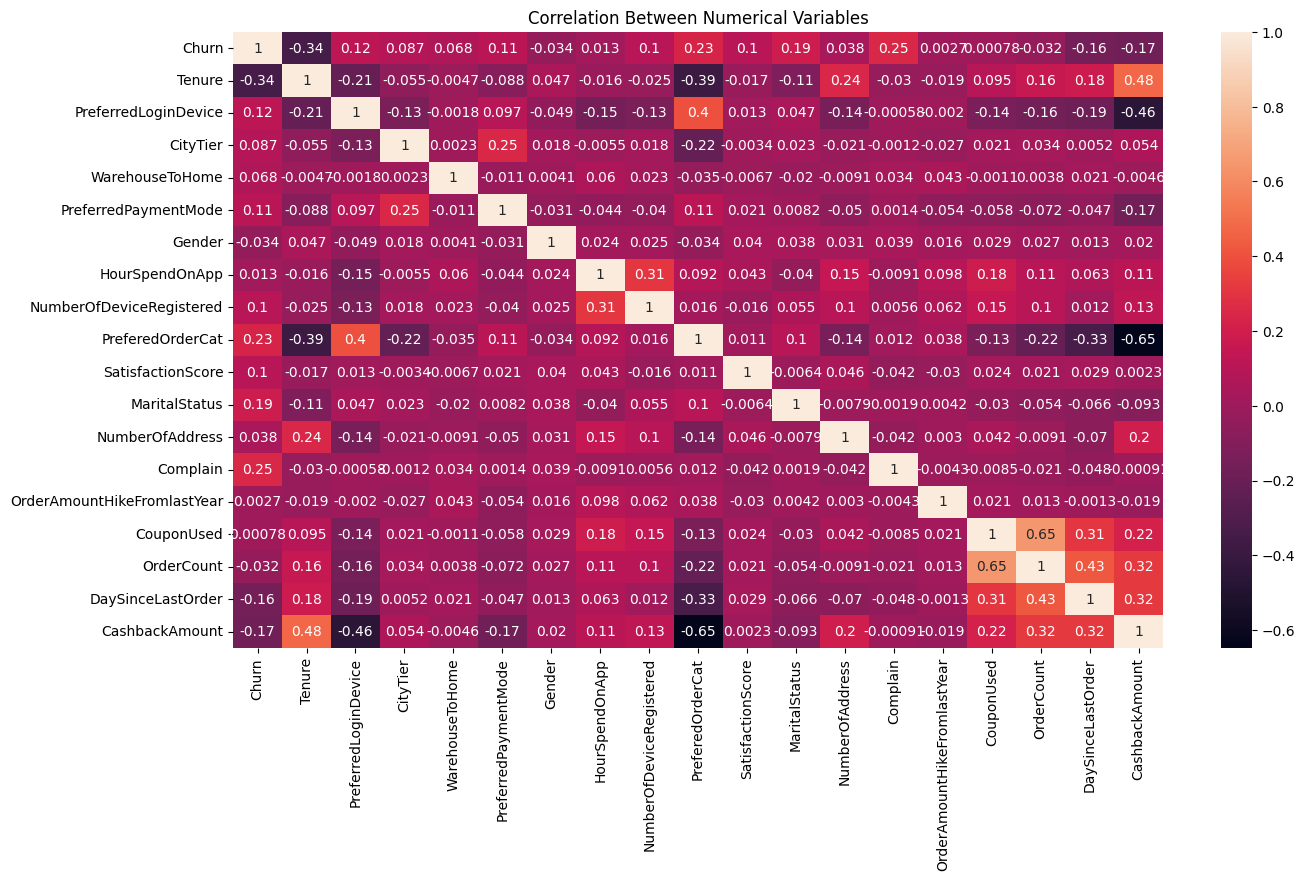

In [30]:
#check correlation
plt.figure(figsize = (15, 8))
corr = train_encoded.corr()
sns.heatmap(corr, annot = True)
plt.title('Correlation Between Numerical Variables')
plt.show()

there is no extreme multicolinearity on the data

### Scaling for Logistic Regression (Base Model)

In [31]:
train_encoded.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
CustomerID,,,,,,,,,,,,,,,,,,,
54479,0,1.0,0.124943,1,12.0,0.156098,1,3.0,4,0.280000,4,0.271022,3,1,13.0,1.0,2.0,3.0,149.78
53686,0,17.0,0.124943,1,13.0,0.133838,1,4.0,5,0.105231,3,0.271022,3,1,15.0,2.0,2.0,9.0,165.81
50732,0,0.0,0.228106,1,9.0,0.156098,0,3.0,4,0.271186,3,0.271022,2,0,12.0,0.0,1.0,2.0,130.33
50292,0,9.0,0.200305,1,8.0,0.156098,0,2.0,3,0.280000,2,0.142003,2,1,23.0,1.0,1.0,0.0,117.02
50185,0,4.0,0.228106,1,11.0,0.271812,0,2.0,3,0.280000,2,0.142003,1,1,12.0,0.0,1.0,3.0,148.21


In [32]:
train_encoded.describe()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.00000,4504.000000,4504.000000,4504.000000
mean,0.169405,10.146314,0.169405,1.659192,15.610568,0.169405,0.392096,2.937389,3.689387,0.169405,3.061723,0.169405,4.196714,0.287078,15.700933,1.73468,2.979796,4.434281,177.146754
std,0.375151,8.413616,0.044717,0.916920,8.434684,0.039719,0.488272,0.704723,1.023210,0.086308,1.379624,0.070195,2.572930,0.452449,3.600656,1.85518,2.884988,3.551047,49.124316
min,0.000000,0.000000,0.124943,1.000000,5.000000,0.133838,0.000000,0.000000,1.000000,0.048485,1.000000,0.116027,1.000000,0.000000,11.000000,0.00000,1.000000,0.000000,0.000000
25%,0.000000,3.000000,0.124943,1.000000,9.000000,0.133838,0.000000,2.000000,3.000000,0.105231,2.000000,0.116027,2.000000,0.000000,13.000000,1.00000,1.000000,2.000000,145.700000
50%,0.000000,9.000000,0.200305,1.000000,14.000000,0.156098,0.000000,3.000000,4.000000,0.152411,3.000000,0.116027,3.000000,0.000000,15.000000,1.00000,2.000000,3.000000,163.670000
75%,0.000000,15.000000,0.200305,3.000000,20.000000,0.163934,1.000000,3.000000,4.000000,0.271186,4.000000,0.271022,6.000000,1.000000,18.000000,2.00000,3.000000,7.000000,195.820000
max,1.000000,61.000000,0.228106,3.000000,127.000000,0.271812,1.000000,5.000000,6.000000,0.280000,5.000000,0.271022,22.000000,1.000000,26.000000,16.00000,16.000000,46.000000,324.990000


In [42]:
columns_to_scale = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount','CityTier', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress']

scaler = StandardScaler()
train_df_scaled = train_encoded.copy()
train_df_scaled[columns_to_scale] = scaler.fit_transform(train_df_scaled[columns_to_scale])

test_df_scaled = test_encoded.copy()
test_df_scaled[columns_to_scale] = scaler.transform(test_df_scaled[columns_to_scale])


In [43]:
train_df_scaled.describe()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,4504.000000,4.504000e+03,4504.000000,4.504000e+03,4.504000e+03,4504.000000,4504.000000,4.504000e+03,4.504000e+03,4504.000000,4.504000e+03,4504.000000,4.504000e+03,4504.000000,4.504000e+03,4.504000e+03,4.504000e+03,4.504000e+03,4.504000e+03
mean,0.169405,3.470679e-17,0.169405,-8.479501e-17,-5.008821e-17,0.169405,0.392096,-1.262065e-17,4.417228e-17,0.169405,-1.640685e-16,0.169405,-6.468084e-17,0.287078,-2.328905e-16,7.513232e-17,-3.076284e-17,3.155163e-18,3.273482e-16
std,0.375151,1.000111e+00,0.044717,1.000111e+00,1.000111e+00,0.039719,0.488272,1.000111e+00,1.000111e+00,0.086308,1.000111e+00,0.070195,1.000111e+00,0.452449,1.000111e+00,1.000111e+00,1.000111e+00,1.000111e+00,1.000111e+00
min,0.000000,-1.206074e+00,0.124943,-7.189998e-01,-1.258108e+00,0.133838,0.000000,-4.168611e+00,-2.628675e+00,0.048485,-1.494575e+00,0.116027,-1.242579e+00,0.000000,-1.305722e+00,-9.351507e-01,-6.863168e-01,-1.248863e+00,-3.606491e+00
25%,0.000000,-8.494692e-01,0.124943,-7.189998e-01,-7.838234e-01,0.133838,0.000000,-1.330301e+00,-6.738245e-01,0.105231,-7.696595e-01,0.116027,-8.538741e-01,0.000000,-7.502056e-01,-3.960596e-01,-6.863168e-01,-6.855867e-01,-6.402175e-01
50%,0.000000,-1.362603e-01,0.200305,-7.189998e-01,-1.909671e-01,0.156098,0.000000,8.885475e-02,3.036008e-01,0.152411,-4.474391e-02,0.116027,-4.651689e-01,0.000000,-1.946896e-01,-3.960596e-01,-3.396564e-01,-4.039484e-01,-2.743702e-01
75%,0.000000,5.769487e-01,0.200305,1.462459e+00,5.204604e-01,0.163934,1.000000,8.885475e-02,3.036008e-01,0.271186,6.801717e-01,0.271022,7.009466e-01,1.000000,6.385844e-01,1.430315e-01,7.004018e-03,7.226049e-01,3.801645e-01
max,1.000000,6.044884e+00,0.228106,1.462459e+00,1.320758e+01,0.271812,1.000000,2.927165e+00,2.258451e+00,0.280000,1.405087e+00,0.271022,6.920229e+00,1.000000,2.860648e+00,7.690307e+00,4.513589e+00,1.170650e+01,3.009908e+00


### Feature Selection

In [44]:
X_train = train_df_scaled.drop(columns=['Churn'])
y_train = train_df_scaled['Churn']

X_test = test_df_scaled.drop(columns=['Churn'])
y_test = test_df_scaled['Churn']

## Model Selection

In [45]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}

results = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)

    #predict on train
    y_pred_train = clf.predict(X_train)
    y_pred_train_probs = clf.predict_proba(X_train)[:, 1]

    #predict on test
    y_pred_test = clf.predict(X_test)
    y_pred_test_probs = clf.predict_proba(X_test)[:, 1]

    #evaluate on train
    precision_train = precision_score(y_train, y_pred_train, pos_label=1)
    recall_train = recall_score(y_train, y_pred_train, pos_label=1)
    f1_train = f1_score(y_train, y_pred_train, pos_label=1)
    roc_auc_train = roc_auc_score(y_train, y_pred_train_probs)

    #evaluate on test
    precision_test = precision_score(y_test, y_pred_test, pos_label=1)
    recall_test = recall_score(y_test, y_pred_test, pos_label=1)
    f1_test = f1_score(y_test, y_pred_test, pos_label=1)
    roc_auc_test = roc_auc_score(y_test, y_pred_test_probs)

    #append results to list
    results.append({
        'Model': name,
        'Precision (train)': precision_train,
        'Recall (train)': recall_train,
        'F1-Score (train)': f1_train,
        'ROC AUC (train)': roc_auc_train,
        'Precision (test)': precision_test,
        'Recall (test)': recall_test,
        'F1-Score (test)': f1_test,
        'ROC AUC (test)': roc_auc_test
    })

#create dataframe
results_df = pd.DataFrame(results)
results_df

[LightGBM] [Info] Number of positive: 763, number of negative: 3741
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 460
[LightGBM] [Info] Number of data points in the train set: 4504, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.169405 -> initscore=-1.589850
[LightGBM] [Info] Start training from score -1.589850


,Model,Precision (train),Recall (train),F1-Score (train),ROC AUC (train),Precision (test),Recall (test),F1-Score (test),ROC AUC (test)
0,Logistic Regression,0.741053,0.461337,0.568659,0.880485,0.826923,0.464865,0.595156,0.888595
1,K-Nearest Neighbors,0.883721,0.647444,0.747352,0.973345,0.777778,0.491892,0.602649,0.892245
2,Decision Tree,1.000000,1.000000,1.000000,1.000000,0.845745,0.859459,0.852547,0.914321
3,Random Forest,1.000000,1.000000,1.000000,1.000000,0.987500,0.854054,0.915942,0.990278
4,XGBoost,1.000000,1.000000,1.000000,1.000000,0.972603,0.767568,0.858006,0.978103
5,LightGBM,0.994730,0.989515,0.992116,0.999950,0.911765,0.837838,0.873239,0.981107


Among the models evaluated, **Random Forest** stands out as the best-performing model. although it achieved the second highest recall on the test set (0.854) but it have the highest score in Precission (0.987) and F1-Score (0.916) while maintaining a high ROC AUC score (0.99), it also has the smallest gap between train and test than other models. indicating both strong precision-recall balance and excellent overall classification ability.

While Decision Tree, XGBoost and LightGBM also performed well, their perfect training scores suggest overfitting. In contrast, Random Forest maintains strong generalization without sacrificing performance.

Therefore, Random Forest is the most reliable model for this classification task.

## Model Training and Evaluation with Random Forest

### Base Model

In [58]:
#retrieve model
rf = classifiers['Random Forest']

#fit model
rf.fit(X_train, y_train)

#predict on train and test
base_pred_train = rf.predict(X_train)
base_pred_train_probs = rf.predict_proba(X_train)[:, 1]

base_pred_test = rf.predict(X_test)
base_pred_test_probs = rf.predict_proba(X_test)[:, 1]

#evaluate
base_train_metrics = {
    'Precision': precision_score(y_train, base_pred_train, pos_label=1),
    'Recall': recall_score(y_train, base_pred_train, pos_label=1),
    'F1-Score': f1_score(y_train, base_pred_train, pos_label=1),
    'ROC AUC': roc_auc_score(y_train, base_pred_train_probs)
}

base_test_metrics = {
    'Precision': precision_score(y_test, base_pred_test, pos_label=1),
    'Recall': recall_score(y_test, base_pred_test, pos_label=1),
    'F1-Score': f1_score(y_test, base_pred_test, pos_label=1),
    'ROC AUC': roc_auc_score(y_test, base_pred_test_probs)
}

base_evaluation_df = pd.DataFrame([base_train_metrics, base_test_metrics], index=['Train', 'Test'])
base_evaluation_df

,Precision,Recall,F1-Score,ROC AUC
Train,1.0000,1.000000,1.000000,1.000000
Test,0.9875,0.854054,0.915942,0.990278


### Tuned Random Forest

To reduce the effect of overfitting, the parameters will be tuned using Randomized Search Cross Validation as follows:


In [59]:
# Define model
tuned_rf = RandomForestClassifier(random_state=42)

# Define parameters for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# Set up cross validation (sama seperti sebelumnya)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up f1 scoring (sama seperti sebelumnya)
f1_scorer = make_scorer(f1_score)

# Random search for Random Forest
random_search_rf = RandomizedSearchCV(
    tuned_rf,
    param_grid_rf,
    n_iter=10,
    cv=5,
    scoring=f1_scorer,
    random_state=42
)

# Fit the model
random_search_rf.fit(X_train, y_train)

# The best parameter
print("Best set of hyperparameters: ", random_search_rf.best_params_)
print("Best F1 score: ", random_search_rf.best_score_)

Starting Random Forest hyperparameter tuning...

=== RANDOM FOREST TUNING RESULTS ===
Best set of hyperparameters:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini', 'bootstrap': False}
Best F1 score:  0.9061531432997322


In [61]:
# Retrieve the best Random Forest model from RandomizedSearchCV
tuned_rf_model = random_search_rf.best_estimator_

# Predict on train and test sets
tuned_rf_pred_train = tuned_rf_model.predict(X_train)
tuned_rf_pred_train_probs = tuned_rf_model.predict_proba(X_train)[:, 1]

tuned_rf_pred_test = tuned_rf_model.predict(X_test)
tuned_rf_pred_test_probs = tuned_rf_model.predict_proba(X_test)[:, 1]

# Evaluate performance
tuned_rf_train_metrics = {
    'Precision': precision_score(y_train, tuned_rf_pred_train, pos_label=1),
    'Recall': recall_score(y_train, tuned_rf_pred_train, pos_label=1),
    'F1-Score': f1_score(y_train, tuned_rf_pred_train, pos_label=1),
    'ROC AUC': roc_auc_score(y_train, tuned_rf_pred_train_probs)
}

tuned_rf_test_metrics = {
    'Precision': precision_score(y_test, tuned_rf_pred_test, pos_label=1),
    'Recall': recall_score(y_test, tuned_rf_pred_test, pos_label=1),
    'F1-Score': f1_score(y_test, tuned_rf_pred_test, pos_label=1),
    'ROC AUC': roc_auc_score(y_test, tuned_rf_pred_test_probs)
}

# Create evaluation DataFrame
tuned_rf_evaluation_df = pd.DataFrame([tuned_rf_train_metrics, tuned_rf_test_metrics], index=['Train', 'Test'])
tuned_rf_evaluation_df

,Precision,Recall,F1-Score,ROC AUC
Train,1.000000,1.000000,1.000000,1.000000
Test,0.994012,0.897297,0.943182,0.995066


### Tuned Random Forest with SMOTE

Since the target data is imbalance, we can try to improve using oversampling techniques, such as SMOTE:

In [62]:
# Define model
smote_rf = RandomForestClassifier(random_state=42)

# Define parameters for Random Forest
param_grid_rf = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [10, 20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None],
    'rf__bootstrap': [True, False],
    'rf__criterion': ['gini', 'entropy']
}

# Set up pipeline
pipeline_rf = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),  # apply SMOTE to training data within each fold
    ('rf', smote_rf)
])

# Set up cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up scoring
f1_scorer = make_scorer(f1_score)

# Random search
smote_random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_grid_rf,
    n_iter=10,
    cv=cv,
    scoring=f1_scorer,
    random_state=42,
    verbose=1,
)

# Fit
smote_random_search_rf.fit(X_train, y_train)

# The best parameter
print("Best set of hyperparameters: ", smote_random_search_rf.best_params_)
print("Best F1 score: ", smote_random_search_rf.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best set of hyperparameters:  {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 20, 'rf__criterion': 'entropy', 'rf__bootstrap': False}
Best F1 score:  0.8482813042334769


In [63]:
# Retrieve model
smote_rf_model = smote_random_search_rf.best_estimator_

# Predict on train and test
smote_rf_pred_train = smote_rf_model.predict(X_train)
smote_rf_pred_train_probs = smote_rf_model.predict_proba(X_train)[:, 1]

smote_rf_pred_test = smote_rf_model.predict(X_test)
smote_rf_pred_test_probs = smote_rf_model.predict_proba(X_test)[:, 1]

# Evaluate
smote_rf_train_metrics = {
    'Precision': precision_score(y_train, smote_rf_pred_train, pos_label=1),
    'Recall': recall_score(y_train, smote_rf_pred_train, pos_label=1),
    'F1-Score': f1_score(y_train, smote_rf_pred_train, pos_label=1),
    'ROC AUC': roc_auc_score(y_train, smote_rf_pred_train_probs)
}

smote_rf_test_metrics = {
    'Precision': precision_score(y_test, smote_rf_pred_test, pos_label=1),
    'Recall': recall_score(y_test, smote_rf_pred_test, pos_label=1),
    'F1-Score': f1_score(y_test, smote_rf_pred_test, pos_label=1),
    'ROC AUC': roc_auc_score(y_test, smote_rf_pred_test_probs)
}

smote_rf_evaluation_df = pd.DataFrame([smote_rf_train_metrics, smote_rf_test_metrics], index=['Train', 'Test'])
smote_rf_evaluation_df

,Precision,Recall,F1-Score,ROC AUC
Train,1.00000,1.000000,1.00000,1.0000
Test,0.56129,0.940541,0.70303,0.9704


### Model Analysis

In [64]:
evaluation_rf_df = pd.DataFrame([base_train_metrics, base_test_metrics,
                              tuned_rf_train_metrics, tuned_rf_test_metrics,
                              smote_rf_train_metrics,smote_rf_test_metrics],
                             index = ['Base Random Forest Train', 'Base Random Forest Test',
                                      'Tuned Random Forest(without SMOTE) Train', 'Tuned Random Forest(without SMOTE) Test',
                                      'Tuned Random Forest with SMOTE Train', 'Tuned Random Forest with SMOTE Test'])
evaluation_rf_df

,Precision,Recall,F1-Score,ROC AUC
Base Random Forest Train,1.000000,1.000000,1.000000,1.000000
Base Random Forest Test,0.987500,0.854054,0.915942,0.990278
Tuned Random Forest(without SMOTE) Train,1.000000,1.000000,1.000000,1.000000
Tuned Random Forest(without SMOTE) Test,0.994012,0.897297,0.943182,0.995066
Tuned Random Forest with SMOTE Train,1.000000,1.000000,1.000000,1.000000
Tuned Random Forest with SMOTE Test,0.561290,0.940541,0.703030,0.970400


**Observations:**

- Tuned Random Forest shows  improvement over the base model in all metrics (precision, recall, F1-score, and ROC-AUC), indicating that base XGBoost model is a better balance between precision and recall. It shows that hyperparameter tuning unsuccessfully enhanced the model's performance without compromising generalization.
- and SMOTE implementation slightly reduces the overall performance (precision, F1-score, ROC-AUC drops). This is likely due to introducing noise in the synthetic samples, making it less effective compared to the tuned model without SMOTE.


The **Tuned Random Forest** is the best-performing model. It provides the highest Precision, F1-Score, and ROC AUC, and second highest in Recall. indicating a robust and balanced performance.

### Performa Model Prediksi Customer Churn

<Figure size 800x600 with 0 Axes>

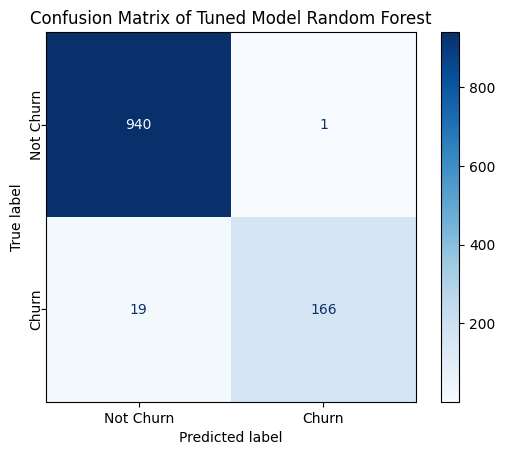

In [70]:
#confusion matrix of base XGBoost

cm_tuned = confusion_matrix(y_test, tuned_rf_pred_test)
tuned_display = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Not Churn', 'Churn'])

plt.figure(figsize=(8, 6))
tuned_display.plot(cmap='Blues', values_format='d')
plt.yticks(rotation=90, ha='center', va='center')
plt.title('Confusion Matrix of Tuned Model Random Forest')
plt.show()

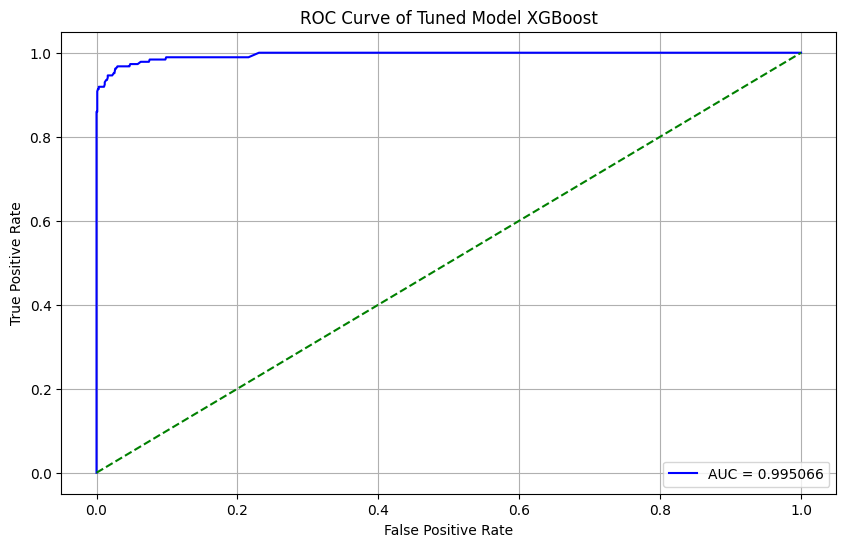

In [71]:
#check ROC-AUC curve and result

tuned_fpr, tuned_tpr, tuned_thresholds = roc_curve(y_test, tuned_rf_pred_test_probs)
tuned_roc_auc = roc_auc_score(y_test, tuned_rf_pred_test_probs)

plt.figure(figsize=(10, 6))
plt.plot(tuned_fpr, tuned_tpr, color='blue', label=f'AUC = {tuned_roc_auc:.6f}')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.title('ROC Curve of Tuned Model XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

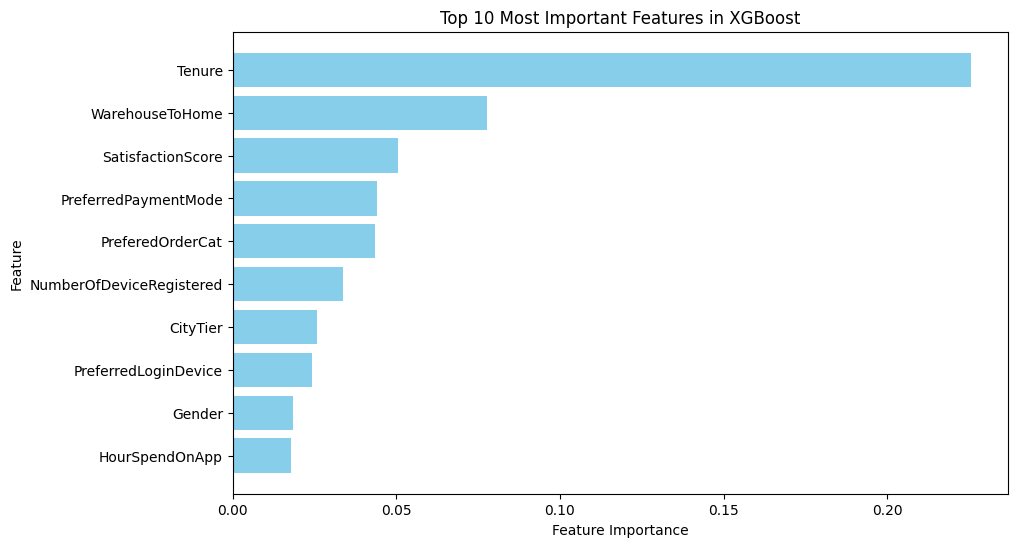

                    Feature  Importance
0                    Tenure    0.225485
3           WarehouseToHome    0.077795
9         SatisfactionScore    0.050624
4      PreferredPaymentMode    0.044088
8          PreferedOrderCat    0.043429
7  NumberOfDeviceRegistered    0.033617
2                  CityTier    0.025668
1      PreferredLoginDevice    0.024166
5                    Gender    0.018311
6            HourSpendOnApp    0.017904


In [72]:
importances = tuned_rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

top_10_features = feature_importance_df.head(10).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features in XGBoost')
plt.gca().invert_yaxis()  # To display the most important features at the top
plt.show()

print(top_10_features)

**Actionable Insights Based on Feature Importance for E-Commerce Customer Churn Prediction**

**1. Tenure: The Most Critical Factor (22.5% importance)**
- Implement progressive loyalty programs with milestones at 3, 6, and 12 months
- Create targeted onboarding experience for customers with tenure < 3 months (highest risk)
- Develop "anniversary rewards" for customers reaching 1-year tenure
- Implement early-intervention campaigns for low-tenure customers showing churn signals

**2. WarehouseToHome: Significant Logistics Impact (7.8% impact)**
- Optimize delivery promise based on warehouse-to-home distance
- Implement expedited shipping options for distant customers
- Develop strategic warehouse placement to reduce average delivery distance
- Create distance-based delivery fee structure to maintain profitability

**3. SatisfactionScore: Key Service Quality Indicator (5.1% influence)**
- Implement real-time satisfaction monitoring with automated follow-up for scores ≤3
- Develop service recovery protocols for dissatisfied customers within 24 hours
- Link satisfaction scores to customer service team performance metrics
- Create proactive quality assurance checks for low-satisfaction segments

**4. PreferredPaymentMode: Payment Preferences Matter (4.4% effect)**
- Optimize payment success rates for top preferred methods (COD, digital wallets, credit cards)
- Implement payment failure retry mechanisms with alternative suggestions
- Develop payment security assurance messaging for concerned customers
- Create incentives for adopting low-failure-rate payment methods

**5. PreferedOrderCat: Category Preferences Drive Retention (4.3% importance)**
- Develop hyper-personalized recommendations based on category preferences
- Implement category-specific subscription models for frequent purchasers
- Create cross-category promotion strategies to increase basket diversity
- Launch "category expert" content and curation for engaged shoppers

**6. NumberOfDeviceRegistered: Multi-Device Usage Patterns (3.4% impact)**
- Implement seamless cross-device shopping experience
- Develop device-based personalization (mobile vs desktop preferences)
- Create security features for multi-device users with easy management
- Offer synced cart and wishlist across all registered devices

**7. CityTier: Geographic Segmentation Value (2.6% influence)**
- Customize delivery options and timelines by city tier
- Develop tier-specific marketing campaigns and inventory allocation
- Implement localized promotions based on city-tier spending patterns
- Optimize service coverage and support resources by tier priority

**8. PreferredLoginDevice: Access Behavior Insights (2.4% effect)**
- Optimize UX/UI for most frequently used login devices
- Implement device-specific performance monitoring and optimization
- Develop security features tailored to device login patterns
- Create push notification strategies based on device usage frequency

**9. Gender: Demographic Considerations (1.8% impact)**
- While impact is modest, incorporate gender insights into personalized messaging
- Develop gender-specific product discovery features where relevant
- Create targeted campaigns based on combined gender and preference data
- Avoid over-segmentation while maintaining personalization relevance

**10. HourSpendOnApp: Engagement Metric (1.8% importance)**
- Implement engagement-boosting features for low-usage segments
- Develop "time well spent" app experiences to increase session duration
- Create personalized content feeds to maintain user interest
- Monitor app performance issues that may reduce time spent

---

**General Recommendations:**
- Focus **70% of churn prevention efforts** on managing Tenure, WarehouseToHome, and Satisfaction factors
- Implement real-time churn risk scoring combining top 5 predictors
- Develop automated intervention workflows for high-risk customer segments
- Regularly validate feature importance quarterly as business evolves

**Priority Implementation Timeline:**

**Immediate (0-30 days):**
- Build Tenure-based customer segmentation dashboard
- Implement satisfaction score trigger alerts for customer service
- Optimize warehouse-to-home delivery mapping

**Short-term (1-3 months):**
- Develop personalized payment experience based on preferences
- Launch category-based recommendation engine enhancement
- Create multi-device experience optimization roadmap

**Medium-term (3-6 months):**
- Implement comprehensive loyalty program tied to tenure
- Develop geographic expansion strategy based on city-tier performance
- Build advanced personalization using combined feature insights

**Long-term (6+ months):**
- Deploy AI-driven customer experience platform
- Establish predictive lifetime value modeling system
- Implement continuous feature importance monitoring framework

---

**Success Metrics to Track:**
- Churn rate reduction by tenure segment
- Satisfaction score improvement trends
- Delivery experience NPS by distance
- Payment method success rates
- Category engagement depth increases